In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

In [2]:
here=os.getcwd()
#get path structure
camb_dir=os.path.join(here, 'CAMB')
print(here)
print(camb_dir)
#insert camb directory to path
sys.path.insert(0, camb_dir)
import camb

print ("camb version: ", camb.__version__)
print ("camb path: ", camb.__path__)


/home/maddaba/astrocosmolib/tutorial_new
/home/maddaba/astrocosmolib/tutorial_new/CAMB
camb version:  1.6.0
camb path:  ['/home/maddaba/astrocosmolib/tutorial_new/CAMB/camb']


guardo https://camb.readthedocs.io/en/latest/CAMBdemo.html

In [3]:
pars = camb.set_params(H0=67.5, 
                       ombh2=0.022, # Densità barionica (Ω_b * h^2)
                       omch2=0.122, # Densità della CDM (Ω_c * h^2)
                       mnu=0.06, #sum of neutrino masses in eV
                       omk=0, #curvature
                       tau=0.06,  #reionization optical depth
                       As=2e-9, #scalar amplitude
                       ns=0.965 #scalar spectral index
                       ) #lmax



In [4]:
pars

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2500
 max_l_tensor = 600
 max_eta_k = 5000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.022
 omch2 = 0.122
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.5
 TCMB = 2.7255
 YHe = 0.24569492503497048
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.965
   nrun =

Background

In [5]:
results = camb.get_background(pars)  #risolve le equa di friedmann

In [6]:
#camb--> calculations results
a=np.logspace(-8,0,1000)
z=1.0/a-1.0
comoving_radial_distance = results.comoving_radial_distance(z)

<function matplotlib.pyplot.show(close=None, block=None)>

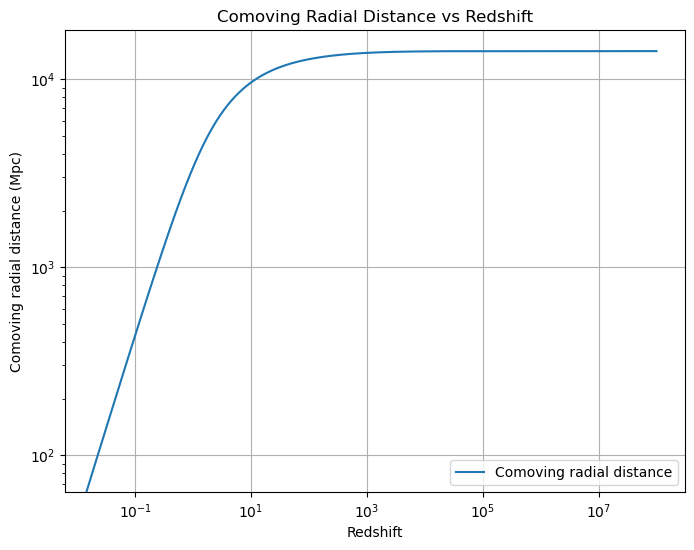

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(z, comoving_radial_distance, label='Comoving radial distance')
plt.xlabel('Redshift')
plt.ylabel('Comoving radial distance (Mpc)')
plt.xscale('log')
plt.yscale('log')
plt.title('Comoving Radial Distance vs Redshift')
plt.legend()
plt.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

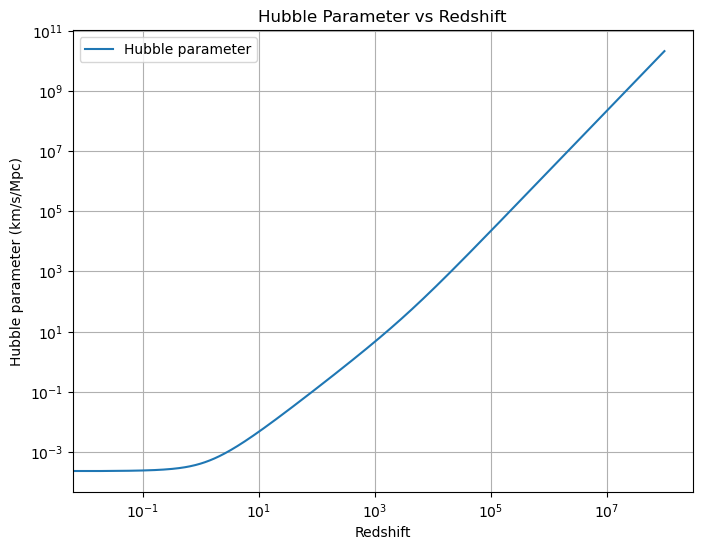

In [8]:
h_of_z=results.h_of_z(z)
plt.figure(figsize=(8, 6))
plt.plot(z, h_of_z, label='Hubble parameter')
plt.xlabel('Redshift')
plt.ylabel('Hubble parameter (km/s/Mpc)')
plt.xscale('log')
plt.yscale('log')
plt.title('Hubble Parameter vs Redshift')
plt.legend()
plt.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

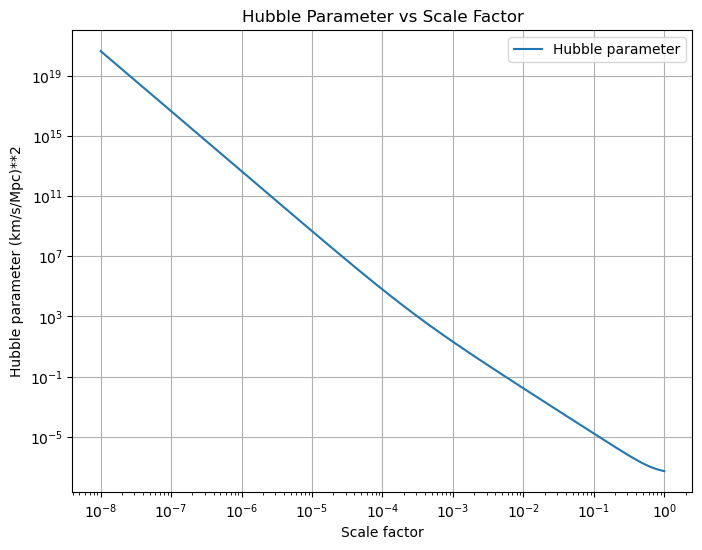

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(a,h_of_z**2, label='Hubble parameter')
plt.xlabel('Scale factor')
plt.ylabel('Hubble parameter (km/s/Mpc)**2')
plt.xscale('log')
plt.yscale('log')
plt.title('Hubble Parameter vs Scale Factor')
plt.legend()
plt.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

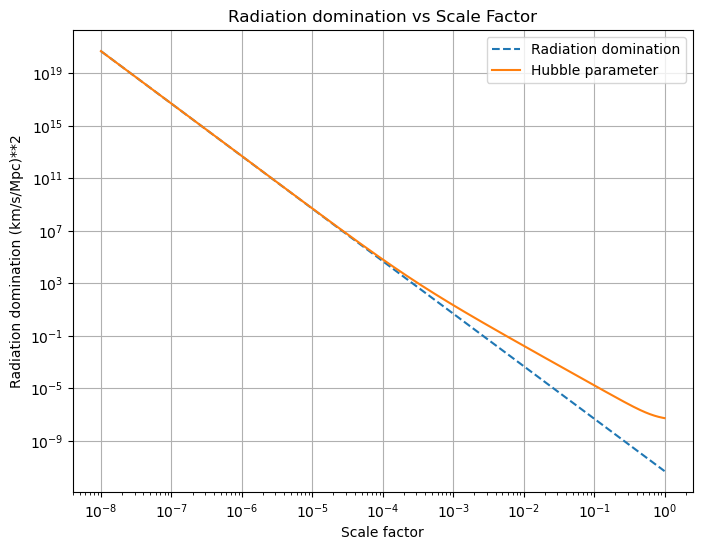

In [10]:
_radiation_domination_H2= (a/a[0])**(-4)*h_of_z[0]**2
plt.figure(figsize=(8, 6))
plt.plot(a, _radiation_domination_H2, label='Radiation domination',linestyle='--')
plt.plot(a,h_of_z**2, label='Hubble parameter')
plt.xlabel('Scale factor')
plt.ylabel('Radiation domination (km/s/Mpc)**2')
plt.xscale('log')
plt.yscale('log')
plt.title('Radiation domination vs Scale Factor')
plt.legend()
plt.grid()
plt.show

Thermal History

In [11]:
a=np.logspace(-8,0,1000)
z=1.0/a-1.0

thermo_results=results.get_background_redshift_evolution(z,vars=['x_e','opacity','visibility','cs2b','T_b','dopacity','ddopacity','dvisibility','ddvisibility'],format='dict')

In [12]:
thermo_results.keys()

dict_keys(['x_e', 'opacity', 'visibility', 'cs2b', 'T_b', 'dopacity', 'ddopacity', 'dvisibility', 'ddvisibility'])

<function matplotlib.pyplot.show(close=None, block=None)>

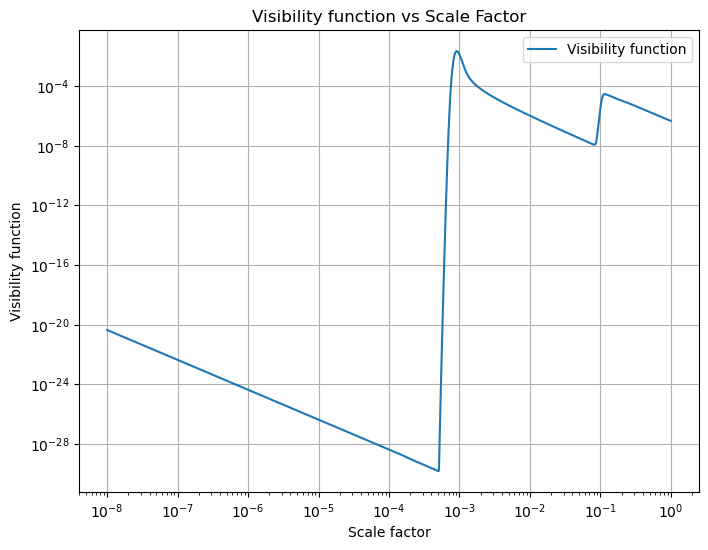

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(a, thermo_results['visibility'], label='Visibility function')
plt.xlabel('Scale factor')
plt.ylabel('Visibility function')
plt.xscale('log')
plt.yscale('log')
plt.title('Visibility function vs Scale Factor')
plt.legend()
plt.grid()
plt.show


droppa come una power law, è sostanzialmente 0 perche uni è opticsal thick fino a ricomb quando ha delta funct e poi inizia a risalire con riionizz .
i due picchi sono ricomb e riioniz

<function matplotlib.pyplot.show(close=None, block=None)>

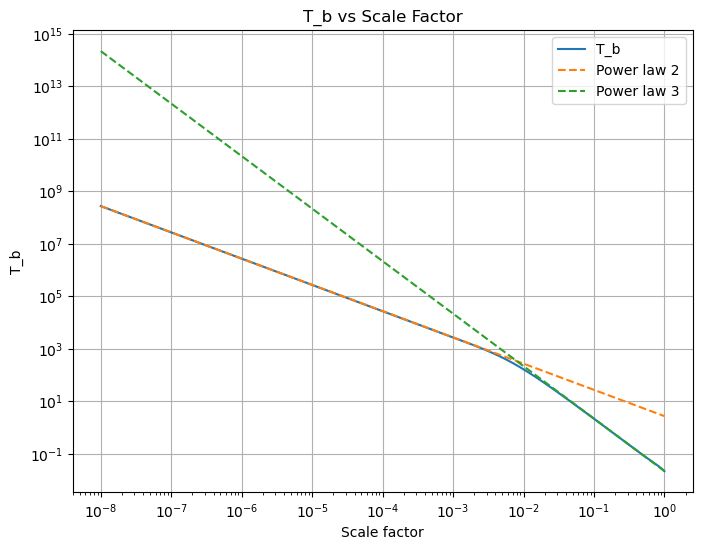

In [14]:
#get two power laws
_power_1=(a/a[0])**(-1)*thermo_results['T_b'][0]
_power_2=(a/a[-1])**(-2)*thermo_results['T_b'][-1]


#adapt to barion T
plt.figure(figsize=(8, 6))
plt.plot(a, thermo_results['T_b'], label='T_b')
plt.plot(a, _power_1, label='Power law 2', linestyle='--')
plt.plot(a, _power_2, label='Power law 3', linestyle='--')
plt.xlabel('Scale factor')
plt.ylabel('T_b')
plt.xscale('log')
plt.yscale('log')
plt.title('T_b vs Scale Factor')
plt.legend()
plt.grid()
plt.show

NB noto che che sono due power law --> aggiungo la parte delle power law nel plot

NB la ricomb avviene a 10-3, ma la temp iniza a raffreddarsi a 10-2, per il barion drug: ci sono cosi tanti fotoni che la coda dei fotoni tiene in 
equil i barioni ancora per un po'

NB la derivata log della opacity è la visibilità

Perturbations 

In [15]:

a=np.logspace(-10,0,1000)
z=1.0/a-1.0
eta=results.conformal_time(z)

In [16]:
#spline interpolation of eta as function of a
from scipy.interpolate import interp1d

eta_of_a = interp1d(a, eta, kind='cubic', fill_value="extrapolate")

<function matplotlib.pyplot.show(close=None, block=None)>

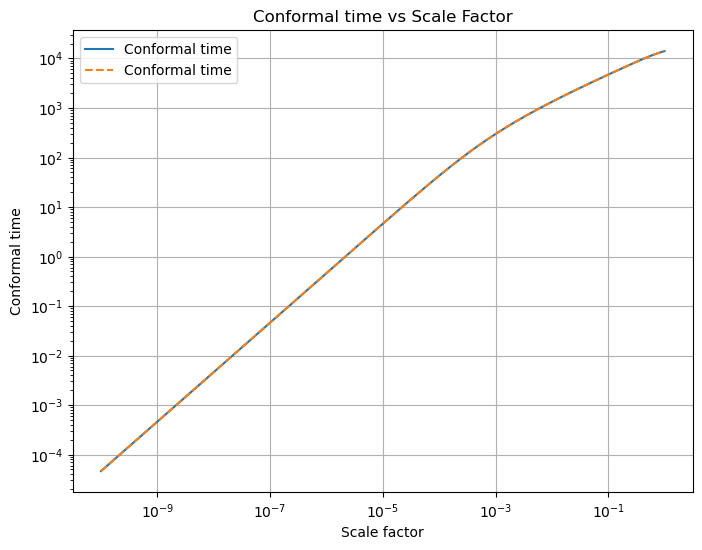

In [17]:
#plot a and eta log log
plt.figure(figsize=(8, 6))
plt.plot(a, eta, label='Conformal time')
plt.plot(a, eta_of_a(a), label='Conformal time', linestyle='--')
plt.xlabel('Scale factor')
plt.ylabel('Conformal time')
plt.xscale('log')
plt.yscale('log')
plt.title('Conformal time vs Scale Factor')
plt.legend()
plt.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

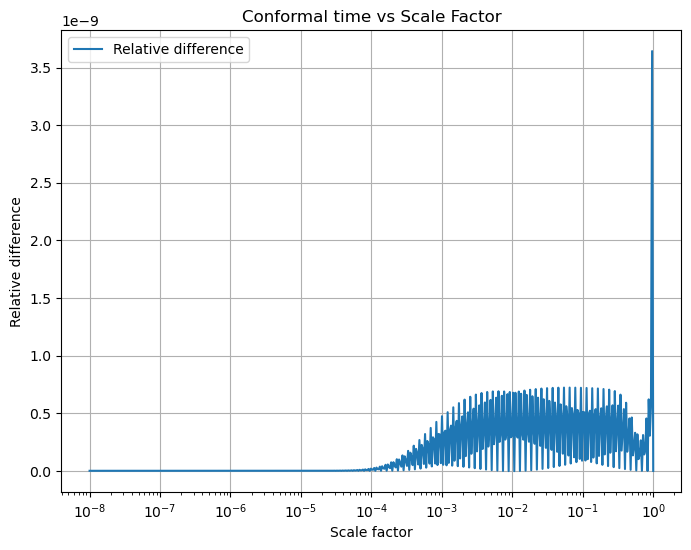

In [ ]:
a_sub=np.logspace(-8,0,500)
eta_sub=results.conformal_time(1.0/a_sub-1.0)
relative_difference = (eta_of_a(a_sub) - eta_sub) / eta_of_a(a_sub)
#plot a and eta log log
plt.figure(figsize=(8, 6))
plt.plot(a_sub, relative_difference, label='Relative difference')
plt.xlabel('Scale factor')
plt.ylabel('Relative difference')
plt.xscale('log')
#plt.yscale('log')
plt.title('Relative difference vs Scale Factor')
plt.legend()
plt.grid()
plt.show

Observables

In [19]:
a=np.logspace(-8,0,1000)
k=[1.e-3,0.1,1.0]
ev= results.get_time_evolution(k,eta_of_a(a))
variables=camb.model.evolve_names
for i in range(len(variables),4):
    print("," .join(variables[i:i+4]))

<function matplotlib.pyplot.show(close=None, block=None)>

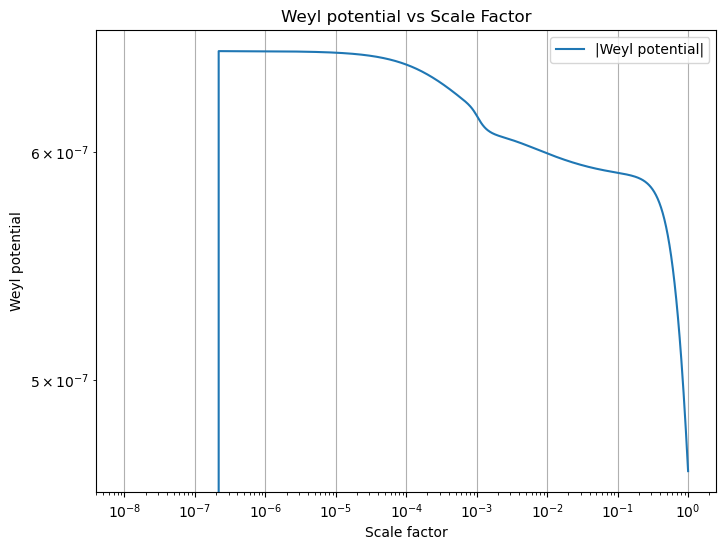

In [20]:
#extract the weil potential evolution
weil_potential=ev[0,:,variables.index('Weyl')]
#plotta weyl potential vs scale factor
plt.figure(figsize=(8, 6))
plt.plot(a,np.abs(weil_potential), label='|Weyl potential|')
plt.xlabel('Scale factor')
plt.ylabel('Weyl potential')
plt.xscale('log')
plt.yscale('log')
plt.title('Weyl potential vs Scale Factor')
plt.legend()
plt.grid()
plt.show

vedo è costante e poi a matter rad equal droppa a 9/10 per dark energy dom

<function matplotlib.pyplot.show(close=None, block=None)>

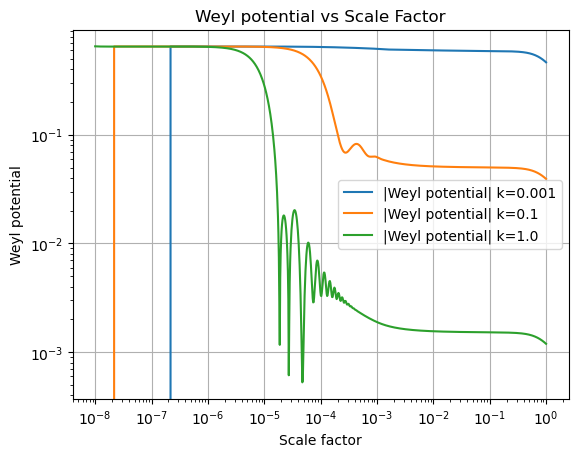

In [21]:
#plot all k modes
for i, k_mode in enumerate(k):
    weyl_potential=ev[i,:,variables.index('Weyl')]
    plt.plot(a,np.abs(weyl_potential)/k_mode**2, label=f'|Weyl potential| k={k_mode}')
plt.xlabel('Scale factor')
plt.ylabel('Weyl potential')
plt.xscale('log')
plt.yscale('log')
plt.title('Weyl potential vs Scale Factor')
plt.legend()
plt.grid()
plt.show


k1 è il primo ad entrare in rad dom: dopra orizz è costantye, sotto oscilla ed ampiezza decade, poi in matter dom è costante e poi decade in dm dom
k2 entra a rad matter equal inizia a decadere ed oscillare e poi diventa subito costante (in matter dom)
k3 è sempre sotto orizz e rimane costante, poi cambia equa e poi ritorna costante e 

In [22]:
ev.shape  # 3 cose date, 1000 tempi, 24 variabili

(3, 1000, 24)

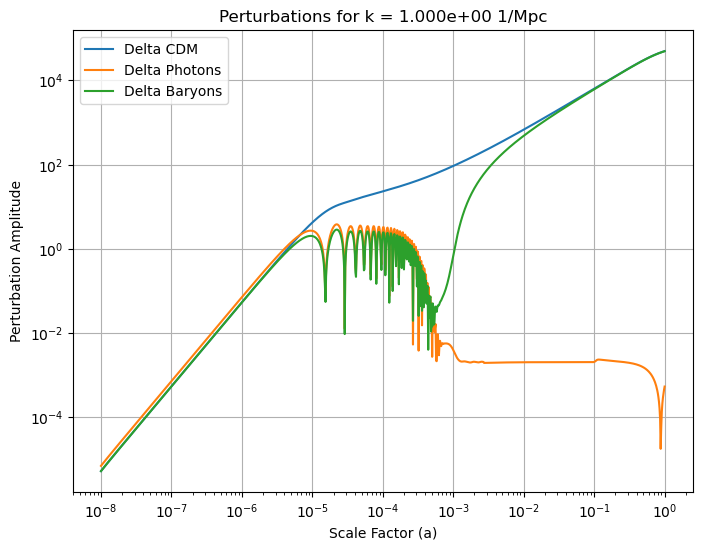

In [23]:
k_mode_index = 2

# Estrai le perturbazioni per il modo k selezionato
delta_cdm = ev[k_mode_index, :, variables.index('delta_cdm')]
delta_photons = ev[k_mode_index, :, variables.index('delta_photon')]
delta_baryons = ev[k_mode_index, :, variables.index('delta_baryon')]

# Crea il grafico
plt.figure(figsize=(8, 6))
plt.plot(a, np.abs(delta_cdm), label='Delta CDM')
plt.plot(a, np.abs(delta_photons), label='Delta Photons')
plt.plot(a, np.abs(delta_baryons), label='Delta Baryons')

# Aggiungi etichette e formato
plt.xlabel('Scale Factor (a)')
plt.ylabel('Perturbation Amplitude')
plt.title(f'Perturbations for k = {k[k_mode_index]:.3e} 1/Mpc')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

super horizon crescono tutti con amp diversa, fotoni arancioni, barioni verde, cdm blu: sono adiab initial conditions e decidono amp
entrano nell'orizzonte: cdm entra nell'orizzonte, e cresce, mentre bar e fotoni oscillano insieme 
a ricomb barioni sono liberi e cascono nella cdm, mentre fotoni sono per conto loro
sono oscill jeans stable, ad amp costante

ora voglio calcolare pert a tempo fissato ed al variare della scala

In [24]:
zrec=results.get_derived_params()['zstar']
arec=1.0/(1.0+zrec)

a=[arec,1.0]
k=np.logspace(-3,0,600)
ev= results.get_time_evolution(k,eta_of_a(a))
variables=camb.model.evolve_names
for i in range(len(variables),4):
    print("," .join(variables[i:i+4]))

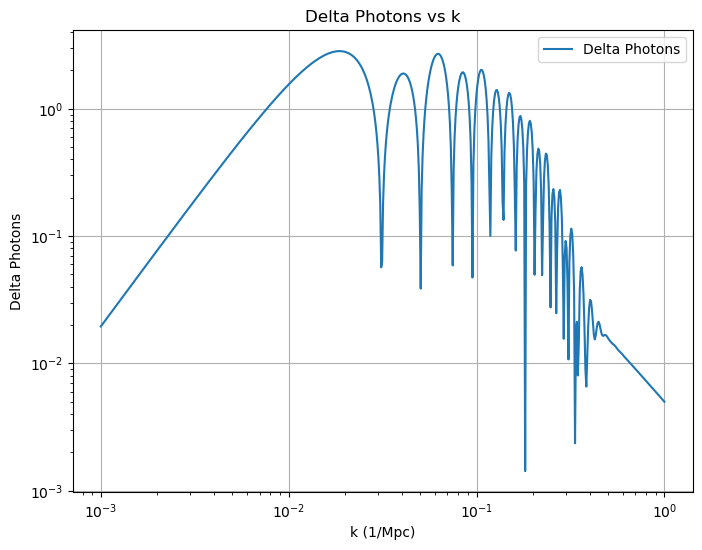

In [25]:
#plot as a function of k il delta photons
delta_photons_at_arec=ev[:,0,variables.index('delta_photon')]
plt.figure(figsize=(8, 6))
plt.plot(k, np.abs(delta_photons_at_arec), label='Delta Photons')
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()

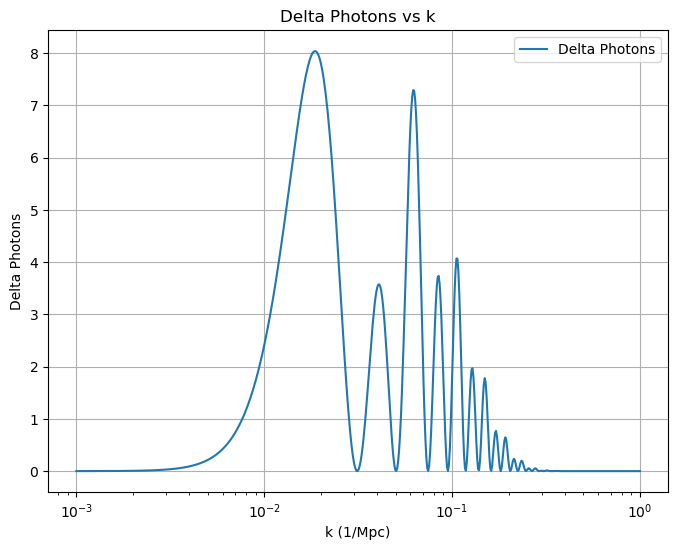

In [26]:
delta_photons_at_arec=ev[:,0,variables.index('delta_photon')]
plt.figure(figsize=(8, 6))
plt.plot(k, (delta_photons_at_arec)**2, label='Delta Photons')
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
#plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()

sembra già un pochino il grafico famoso della CMB, però manca un plateau a grandi scale; il primo picco è il modo che è styato frozen alla ricombinazione
Faccio la time trace del primo modo
voglio pescare k del primo modo  : k=[1.e-3,0.1,1.0]
ci manca il potenziale grav e poi voglio passare da gage sincrona a gage newtoniana

In [27]:
import camb.symbolic as cs 
Delta_gamma_N=cs.make_frame_invariant(cs.Delta_g,'Newtonian')
variables_2=[Delta_gamma_N]

In [28]:
zrec=results.get_derived_params()['zstar']
arec=1.0/(1.0+zrec)

a=[arec,1.0]
k=np.logspace(-3,0,600)
ev= results.get_time_evolution(k,eta_of_a(a))
ev2= results.get_time_evolution(k,eta_of_a(a),variables_2)
variables=camb.model.evolve_names

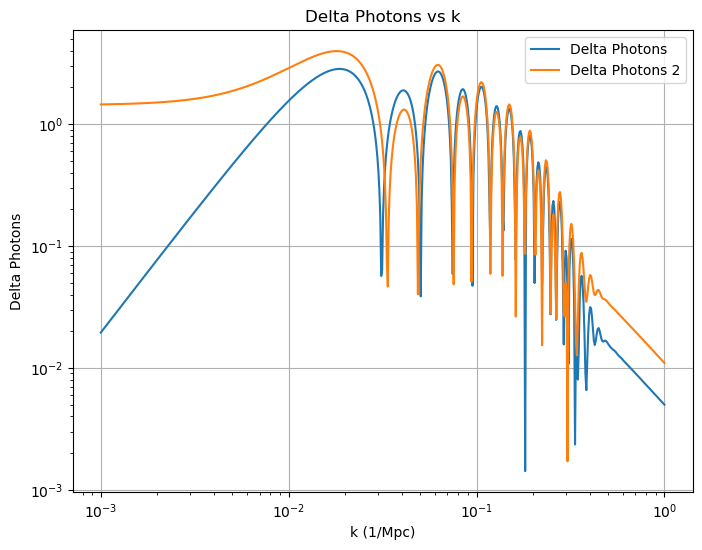

In [29]:
#rifai il plot
delta_photons_at_arec=ev[:,0,variables.index('delta_photon')]
delta_photons_newtonian=ev2[:,0,0]
plt.figure(figsize=(8, 6))
plt.plot(k, np.abs(delta_photons_at_arec), label='Delta Photons')
plt.plot(k, np.abs(delta_photons_newtonian), label='Delta Photons 2')
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()

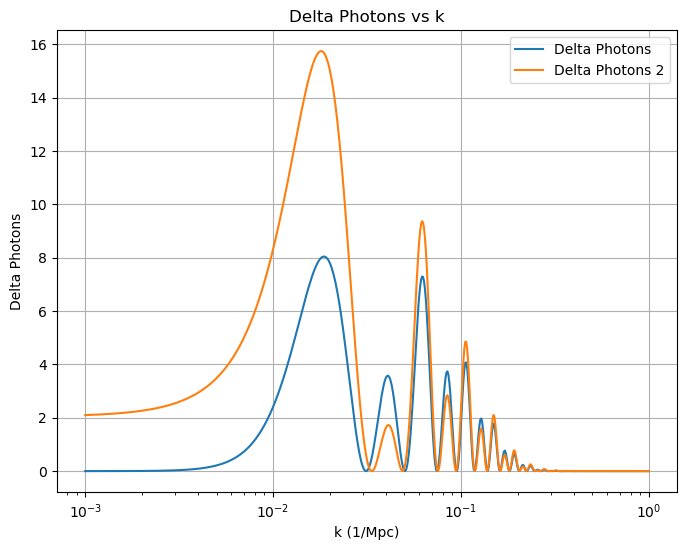

In [30]:
delta_photons_at_arec=ev[:,0,variables.index('delta_photon')]
delta_photons_newtonian=ev2[:,0,0]
plt.figure(figsize=(8, 6))
plt.plot(k, (delta_photons_at_arec)**2, label='Delta Photons')
plt.plot(k, (delta_photons_newtonian)**2, label='Delta Photons 2')
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
#plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()

In [31]:
import camb.symbolic as cs 
Delta_gamma_N=cs.make_frame_invariant(cs.Delta_g,'Newtonian')
variables_2=[Delta_gamma_N,cs.Psi_N]

zrec=results.get_derived_params()['zstar']
arec=1.0/(1.0+zrec)

a=[arec,1.0]
k=np.logspace(-3,0,600)
ev= results.get_time_evolution(k,eta_of_a(a))
ev2= results.get_time_evolution(k,eta_of_a(a),variables_2)
variables=camb.model.evolve_names

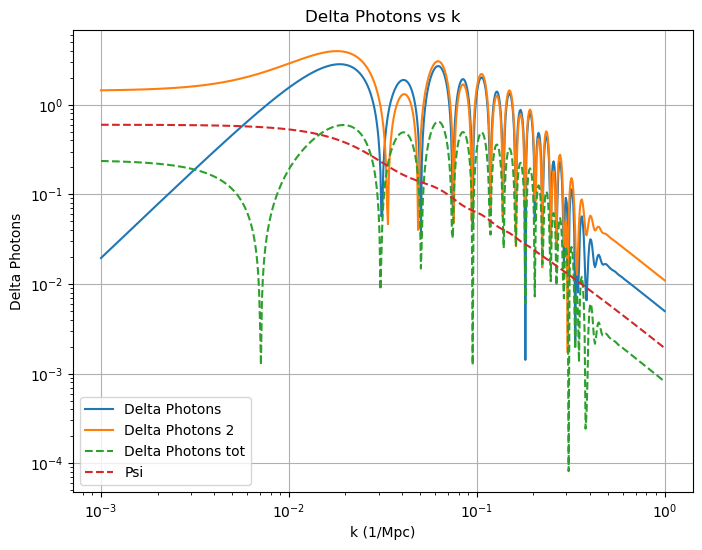

In [32]:
#rifai il plot
delta_photons_at_arec=ev[:,0,variables.index('delta_photon')]
delta_photons_newtonian=ev2[:,0,0]
psi=ev2[:,0,1] #contributo verde : delta tot viene abbassato negativo, così formo il plateau iniziale
delta_tot=delta_photons_newtonian/4. + psi


plt.figure(figsize=(8, 6))
plt.plot(k, np.abs(delta_photons_at_arec), label='Delta Photons')
plt.plot(k, np.abs(delta_photons_newtonian), label='Delta Photons 2')
plt.plot(k, np.abs(delta_tot), label='Delta Photons tot',linestyle='--')
plt.plot(k,np.abs(psi), label='Psi',linestyle='--') 
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()

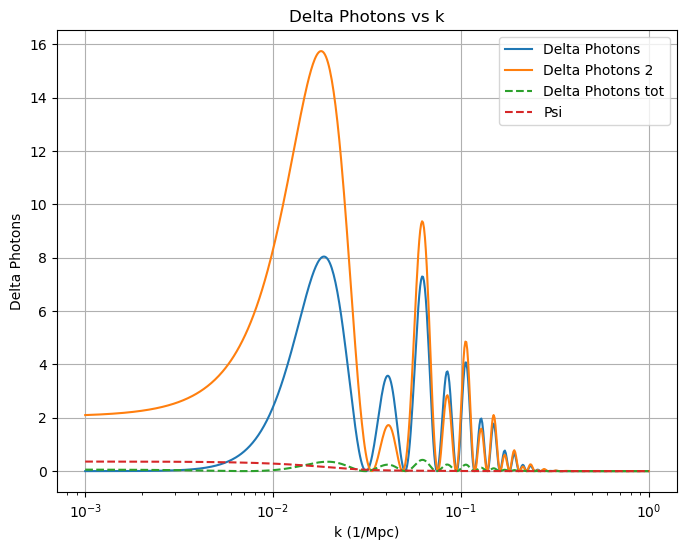

In [33]:
plt.figure(figsize=(8, 6))
plt.plot(k, (delta_photons_at_arec)**2, label='Delta Photons')
plt.plot(k, (delta_photons_newtonian)**2, label='Delta Photons 2')
plt.plot(k, (delta_tot)**2, label='Delta Photons tot',linestyle='--')
plt.plot(k,(psi)**2, label='Psi',linestyle='--') 
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
#plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()

In [34]:
#manca il termine doppler
#voglio la velocità dei fotoni
dir(cs)#dimmi tutto quello che c'è in cs e cerco velocity

['A',
 'Delta_P_b',
 'Delta_P_de',
 'Delta_P_nu',
 'Delta_b',
 'Delta_c',
 'Delta_de',
 'Delta_g',
 'Delta_nu',
 'Delta_r',
 'E_1',
 'E_2',
 'E_3',
 'E_4',
 'E_5',
 'E_eq',
 'Eq',
 'Friedmann',
 'Friedmann_Kfac_subs',
 'Friedmann_subs',
 'Function',
 'G_1',
 'G_2',
 'G_3',
 'G_4',
 'G_5',
 'G_eq',
 'H',
 'H_t',
 'J_1',
 'J_2',
 'J_3',
 'J_4',
 'J_5',
 'J_eq',
 'K',
 'K_fac',
 'K_fac_sub',
 'K_sub',
 'Kf',
 'LinearPerturbation',
 'Newt_vars',
 'Newtonian_subs',
 'Newtonian_var_subs',
 'P',
 'P_t',
 'Phi_N',
 'Pi',
 'Psi_N',
 'Relational',
 'Symbol',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_camb_cache',
 '_default_compiler',
 '_default_flags',
 '_first_compile',
 '_func_cache',
 '_make_index_func',
 '_source_file_count',
 'a',
 'adotoa',
 'background_eqs',
 'camb_fortran',
 'cdm_gauge',
 'cdm_subs',
 'clxg',
 'compile_source_function_code',
 'compile_sympy_to_camb_source_func',
 'component_eqs',
 'cons1',
 'cons2

In [35]:
#prendo la velocità dei fotoni

import camb.symbolic as cs 
Delta_gamma_N=cs.make_frame_invariant(cs.Delta_g,'Newtonian')
vb_N=cs.make_frame_invariant(cs.v_b,'Newtonian')
variables_2=[Delta_gamma_N,cs.Psi_N,vb_N]
#variables_2=[Delta_gamma_N,cs.Psi_N]

zrec=results.get_derived_params()['zstar']
arec=1.0/(1.0+zrec)

a=[arec,1.0]
k=np.logspace(-3,0,600)
ev= results.get_time_evolution(k,eta_of_a(a))
ev2= results.get_time_evolution(k,eta_of_a(a),variables_2)
variables=camb.model.evolve_names

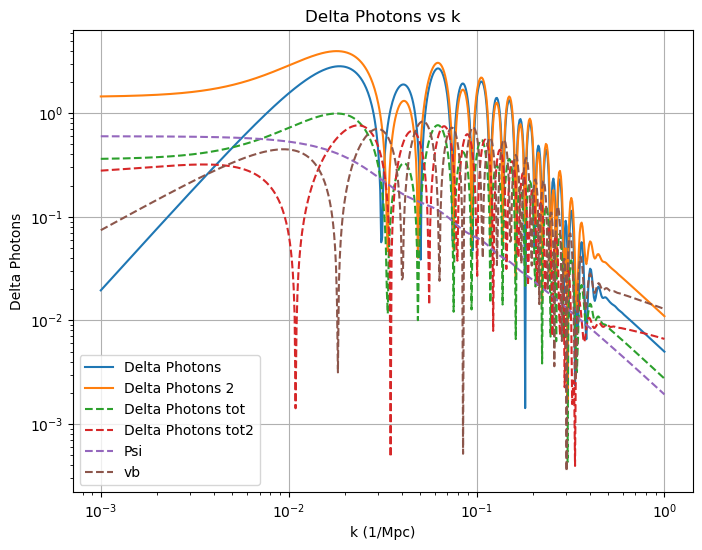

In [43]:
delta_photons_at_arec=ev[:,0,variables.index('delta_photon')]
delta_photons_newtonian=ev2[:,0,0]
psi=ev2[:,0,1] #contributo verde : delta tot viene abbassato negativo, così formo il plateau iniziale
vb=ev2[:,0,2] #contributo blu : delta tot viene abbassato negativo, così formo il plateau iniziale
delta_tot=delta_photons_newtonian/4. 
delta_tot2=delta_photons_newtonian/4. + psi + vb/np.sqrt(3.)


plt.figure(figsize=(8, 6))
plt.plot(k, np.abs(delta_photons_at_arec), label='Delta Photons')
plt.plot(k, np.abs(delta_photons_newtonian), label='Delta Photons 2')
plt.plot(k, np.abs(delta_tot), label='Delta Photons tot ',linestyle='--')
plt.plot(k, np.abs(delta_tot2), label='Delta Photons tot2',linestyle='--')
plt.plot(k,np.abs(psi), label='Psi',linestyle='--') 
plt.plot(k,np.abs(vb), label='vb',linestyle='--')
plt.xlabel('k (1/Mpc)')
plt.ylabel('Delta Photons')
plt.xscale('log')
plt.yscale('log')
plt.title('Delta Photons vs k')
plt.legend()
plt.grid()
plt.show()